# 利用預先訓練的模型來辨識圖像中的物體
    原始圖片>Tensor>model>output
## TorchVision function

In [ ]:
#顯示可用模型
from torchvision import models
dir(models)

: 

## AlexNet
這是一個非常小型的神經網路,主要適合新手認識神經網路
輸入->過濾X5->圖片
其實就是標準的正向運行網路(dorward pass)網路
如果需要獲得所需要的結果需要修矮他的層參數才能緩步實驗獲得


In [ ]:
# AlexNet 使用

## ResNet 
這是殘缺網路,執行下列程式碼後將會開始下載模型,其內部參數高達百萬參數

In [ ]:
from torchvision import models
# ResNet 範例
resnet18 = models.resnet101(pretrained=True)
print(resnet18)

# 最好運行的準備
這裡看到的每一列都是一個模組,我們可以像呼叫函式一樣呼叫resent 這個變數,輸入為圖片輸出為1000個ImageNET類別標籤的信心分數


In [ ]:
from torchvision.transforms import transforms
from torch import mean
Process = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
from PIL import Image
img = Image.open('./dog.png').convert('RGB')
img

In [ ]:
import torch
from torchvision import models
resnet = models.resnet101(pretrained=True)
img_t = Process(img)
img_t.size()
batch_t = torch.unsqueeze(img_t, 0)
batch_t.shape()
resnet.eval()
out = resnet(batch_t)
_,index = torch.max(out, 1)
index[0]





In [ ]:
with open('imagenet_classes.txt') as f:
    labels = [line.strip() for line in f.readlines()]
persentage = torch.nn.functional.softmax(out, dim=1)[0]
labels[index[0]],persentage[index[0]].item()

## GAN生成式對抗網路
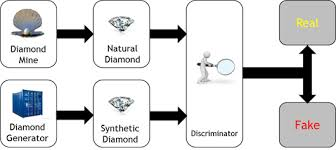

In [ ]:
model_path = './W5/horse2zebra_0.4.0.pth'
model_data = torch.load(model_path)
netG = ResnetGenrator()
netG.load_state_dict(model_data)
netG.eval()

In [ ]:
from PIL import Image
from torchvision import transforms
preprocess = transforms([
    transforms.Resice(256),
    transforms.toTensor()])
img = Image.Open('./W5/horse.jpg')
img

In [ ]:
img_t = preprocess(img)
batch_t = torch.unsqueeze(img_t,0)
batch_out = netG(batch_t)
batch_out = torch.squeeze(batch_out,0)
batch_out = (batch_out+1.0)/2.0
out_img = transforms.ToPILImage()(batch_out)
out_img